In [616]:
!pip3 install nltk

# Question 1

In [617]:
import nltk
from nltk.tokenize import word_tokenize

In [618]:
nltk.download('gutenberg')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

nltk.corpus.gutenberg.fileids()


[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [619]:
paradise_lost = nltk.corpus.gutenberg.words("milton-paradise.txt")
paradise_lost


['[', 'Paradise', 'Lost', 'by', 'John', 'Milton', ...]

In [620]:
stopword = set(nltk.corpus.stopwords.words('english'))
stopword

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [621]:
text_sentences = nltk.corpus.gutenberg.sents("milton-paradise.txt")[:10]

for sentence in text_sentences: 
    
    filtered_list = [word for word in sentence if word.lower() not in stopword]
    print(filtered_list)



['[', 'Paradise', 'Lost', 'John', 'Milton', '1667', ']']
['Book']
['Man', "'", 'first', 'disobedience', ',', 'fruit', 'forbidden', 'tree', 'whose', 'mortal', 'taste', 'Brought', 'death', 'World', ',', 'woe', ',', 'loss', 'Eden', ',', 'till', 'one', 'greater', 'Man', 'Restore', 'us', ',', 'regain', 'blissful', 'seat', ',', 'Sing', ',', 'Heavenly', 'Muse', ',', ',', 'secret', 'top', 'Oreb', ',', 'Sinai', ',', 'didst', 'inspire', 'shepherd', 'first', 'taught', 'chosen', 'seed', 'beginning', 'heavens', 'earth', 'Rose', 'Chaos', ':', ',', 'Sion', 'hill', 'Delight', 'thee', ',', 'Siloa', "'", 'brook', 'flowed', 'Fast', 'oracle', 'God', ',', 'thence', 'Invoke', 'thy', 'aid', 'adventurous', 'song', ',', 'middle', 'flight', 'intends', 'soar', 'th', "'", 'Aonian', 'mount', ',', 'pursues', 'Things', 'unattempted', 'yet', 'prose', 'rhyme', '.']
['chiefly', 'thou', ',', 'Spirit', ',', 'dost', 'prefer', 'temples', 'th', "'", 'upright', 'heart', 'pure', ',', 'Instruct', ',', 'thou', 'know', "'", 'st'

In [622]:
# Stem or lemmatize the words and find counts

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


def clean_words(paradise_lost, stopword):

    """
    Create a function that takes in a list of words and a list of words to remove,
    then return clean_words.

    So I take in words and removes stopwords, punctuations, and single letters.
    Then lower case all of those words and lemmatize them. 
    Finally return a clean_word list.
    """

    words_lemmatized = [lemmatizer.lemmatize(word.lower())
        for word in paradise_lost
        if word.isalpha()
        and word.lower() not in stopword
        and len(word) > 1]
    return words_lemmatized

# Words count
len(paradise_lost)



96825

The reason I chose lemmatize over stem is because although stem can help find root words and faster to process, the root word it return might not make sense, or is not a real english word. However, lemmatize helps finding a form of word thats related in the dictionary, so it consider the context of the word and help return it into a meaningful base form (lemma).  

In [623]:
# Select the top 20 words and create a bar chart.
from collections import Counter
cleaned_words = clean_words(paradise_lost, stopword)

word_counts = Counter(cleaned_words)
top_20 = word_counts.most_common(20)

print(top_20)


[('heaven', 436), ('thou', 432), ('thy', 414), ('thee', 358), ('thus', 318), ('god', 316), ('shall', 283), ('yet', 228), ('earth', 217), ('though', 217), ('u', 187), ('man', 176), ('first', 175), ('day', 157), ('high', 153), ('one', 142), ('son', 132), ('far', 129), ('death', 127), ('may', 126)]


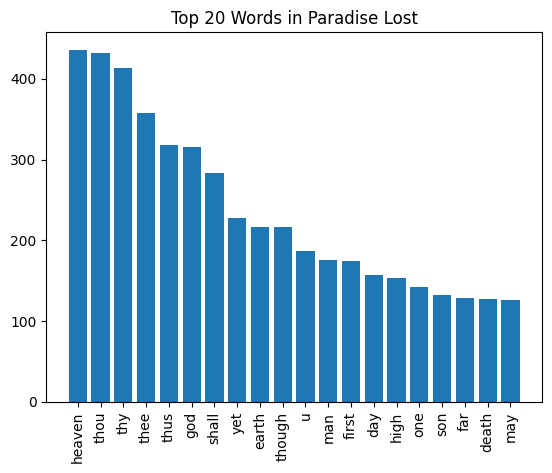

In [624]:
words = []
counts = []
for w in top_20:
    words.append(w[0])
    counts.append(w[1]) 

import matplotlib.pyplot as plt

plt.bar(words, counts)
plt.xticks(rotation = 90)
plt.title("Top 20 Words in Paradise Lost")
plt.show()

# Question 2

In [625]:
nltk.download('vader_lexicon')
nltk.download('subjectivity')
from nltk.classify import NaiveBayesClassifier
from nltk.corpus import subjectivity
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.sentiment.util import *



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package subjectivity to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package subjectivity is already up-to-date!


In [626]:
raw = nltk.corpus.gutenberg.raw("milton-paradise.txt")
sentences_str = nltk.sent_tokenize(raw)

sentences_str = [sent.replace('\n', ' ') for sent in sentences_str]

print(sentences_str[:10])

["[Paradise Lost by John Milton 1667]      Book I      Of Man's first disobedience, and the fruit  Of that forbidden tree whose mortal taste  Brought death into the World, and all our woe,  With loss of Eden, till one greater Man  Restore us, and regain the blissful seat,  Sing, Heavenly Muse, that, on the secret top  Of Oreb, or of Sinai, didst inspire  That shepherd who first taught the chosen seed  In the beginning how the heavens and earth  Rose out of Chaos: or, if Sion hill  Delight thee more, and Siloa's brook that flowed  Fast by the oracle of God, I thence  Invoke thy aid to my adventurous song,  That with no middle flight intends to soar  Above th' Aonian mount, while it pursues  Things unattempted yet in prose or rhyme.", "And chiefly thou, O Spirit, that dost prefer  Before all temples th' upright heart and pure,  Instruct me, for thou know'st; thou from the first  Wast present, and, with mighty wings outspread,  Dove-like sat'st brooding on the vast Abyss,  And mad'st it p

In [627]:
analyzer = SentimentIntensityAnalyzer()

sentiments = []
for sent in sentences_str:
    sentiment = analyzer.polarity_scores(sent)
    sentiments.append((sent))
    
    compound = sentiment['compound']
    pos = sentiment['pos']
    neg = sentiment['neg']
    neu = sentiment['neu']   

    sentiments.append({
    "sentence": sent,
    "compound": compound,
    "positive": pos,
    "negative": neg,
    "neutral": neu})
    
sentiments



["[Paradise Lost by John Milton 1667]      Book I      Of Man's first disobedience, and the fruit  Of that forbidden tree whose mortal taste  Brought death into the World, and all our woe,  With loss of Eden, till one greater Man  Restore us, and regain the blissful seat,  Sing, Heavenly Muse, that, on the secret top  Of Oreb, or of Sinai, didst inspire  That shepherd who first taught the chosen seed  In the beginning how the heavens and earth  Rose out of Chaos: or, if Sion hill  Delight thee more, and Siloa's brook that flowed  Fast by the oracle of God, I thence  Invoke thy aid to my adventurous song,  That with no middle flight intends to soar  Above th' Aonian mount, while it pursues  Things unattempted yet in prose or rhyme.",
 {'sentence': "[Paradise Lost by John Milton 1667]      Book I      Of Man's first disobedience, and the fruit  Of that forbidden tree whose mortal taste  Brought death into the World, and all our woe,  With loss of Eden, till one greater Man  Restore us, a

In [628]:
sentiments_ranking = [item for item in sentiments if isinstance(item, dict)]

most_positive = sorted(sentiments_ranking, key=lambda x: x['positive'], reverse=True)[:5]
most_negative = sorted(sentiments_ranking, key=lambda x: x['negative'], reverse=True)[:5]
most_neutral  = sorted(sentiments_ranking, key=lambda x: x['neutral'], reverse=True)[:5]

print("5 Most positive")
for s in most_positive:
    print(f"Positive Score: {s['positive']}, {s['sentence'][:150]}")
    print()

print("5 Most Negative")
for s in most_negative:
    print(f"Negative Score: {s['negative']}, {s['sentence'][:150]}")
    print()


print("5 Most neutral")
for s in most_neutral:
    print(f"Neutral Score: {s['neutral']}, {s['sentence'][:150]}")
    print()



5 Most positive
Positive Score: 1.0, O friends!

Positive Score: 1.0, O Heaven!

Positive Score: 1.0, O Friends!

Positive Score: 1.0, O Heaven!

Positive Score: 0.838, She fair, divinely fair, fit love for Gods!

5 Most Negative
Negative Score: 1.0, No!

Negative Score: 1.0, O Hell!

Negative Score: 1.0, Alas!

Negative Score: 0.777, Me miserable!

Negative Score: 0.772, Sad cure!

5 Most neutral
Neutral Score: 1.0, Oh how unlike the place from whence they fell!

Neutral Score: 1.0, But see!

Neutral Score: 1.0, Him, haply slumbering on the Norway foam,  The pilot of some small night-foundered skiff,  Deeming some island, oft, as seamen tell,  With fixed ancho

Neutral Score: 1.0, Such resting found the sole  Of unblest feet.

Neutral Score: 1.0, Awake, arise, or be for ever fallen!"



# Question 3

Explain your findings from the previous question. Are the sentences and their sentiment analysis scores correct? Explain why or why not.





I think the result is pretty accurate, although I'm not sure should I rank this by compound score or positive/negative/neutral score it self. But I think it's more accurate when ranking by positive/negative/neutral score. Based on the result, sentences have high positive score have exclamation mark for words that sounds good, like heaven and love. Similarly, those have high negative score contains words that sounds bad, like hell, or sad. 

For most neutral sentences, I don't think they're as accurate as positive or negative. It contains words like unblest, sole, fallen..., most of the sentence sounds more negative than neutral. I guess the sentiment analysis works better for individual word than a whole sentence. 

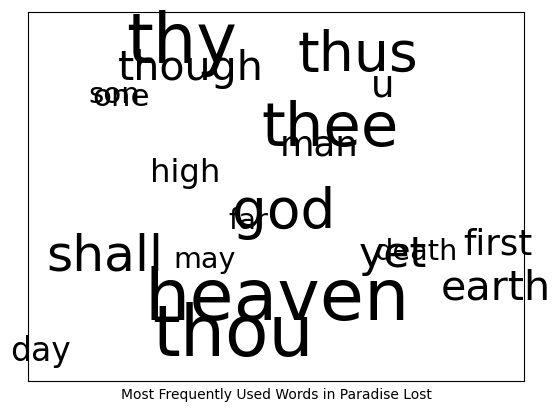

In [633]:
# Extra credit: create a word cloud for your results from question 1

wordcloud_data = [('heaven', 436), ('thou', 432), ('thy', 414), ('thee', 358), ('thus', 318), 
                  ('god', 316), ('shall', 283), ('yet', 228), ('earth', 217), ('though', 217), 
                  ('u', 187), ('man', 176), ('first', 175), ('day', 157), ('high', 153), ('one', 142), 
                  ('son', 132), ('far', 129), ('death', 127), ('may', 126)]

import matplotlib.pyplot as plt
def text_size(total:int) -> float:
    return 8 + total / 200 * 20
for word, popular_word in wordcloud_data:
    plt.text(random.uniform(0,100), random.uniform(0,100), word, 
             ha='center', va='center', size=text_size(popular_word))
plt.xlabel("Most Frequently Used Words in Paradise Lost")
plt.axis([0, 100, 0, 100])
plt.xticks([])
plt.yticks([])
plt.show()